<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES17Sim005.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

dt=2.533e-03, β_eff=1.250, γ_eff=625.000
Late-time λ₀ drift per sample: 0.0000
Late-time u_rms floor: 0.000386


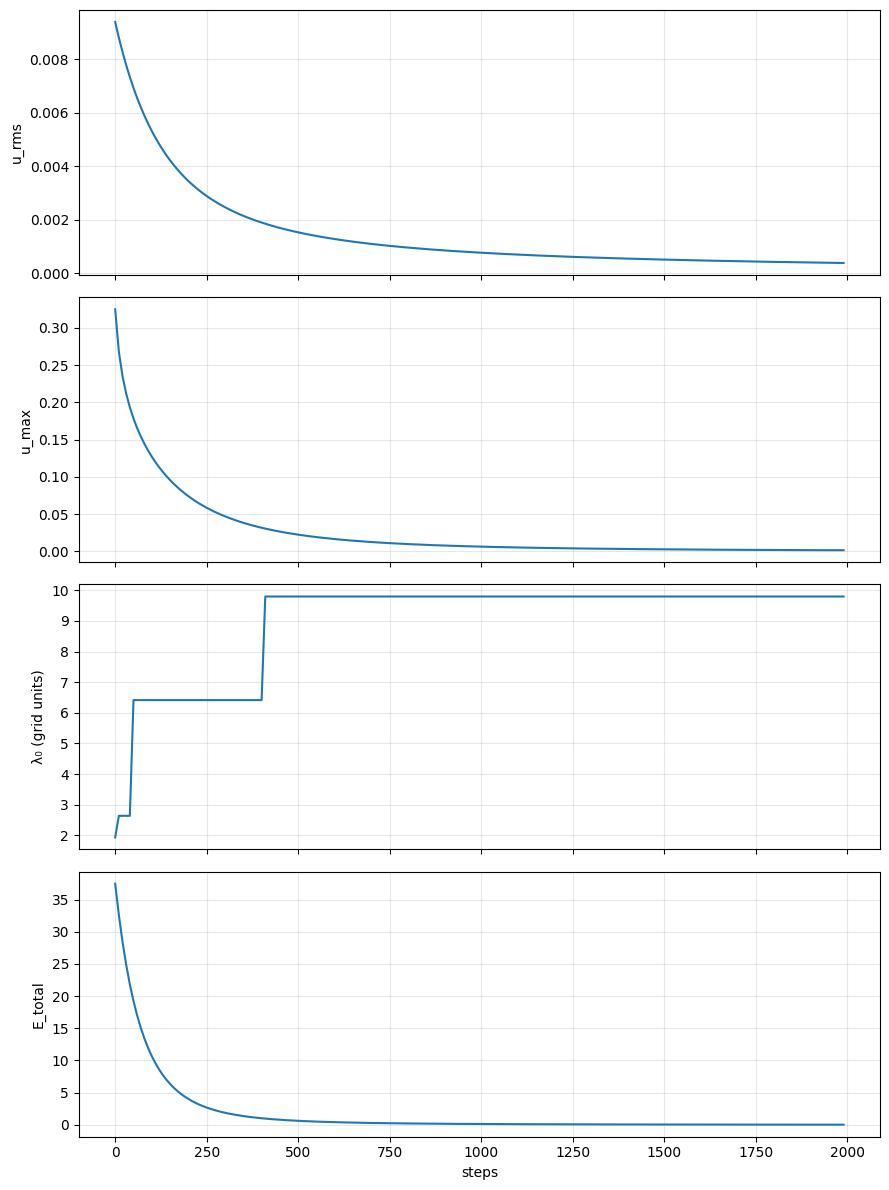

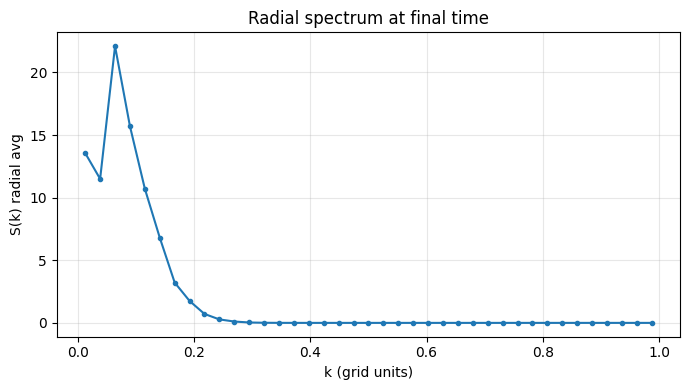

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- Utilities ---
def spectral_laplacian(shape):
    k_axes = [np.fft.fftfreq(n) for n in shape]
    K = np.meshgrid(*k_axes, indexing='ij')
    k2 = np.zeros(shape, dtype=np.float64)
    for Ki in K: k2 += Ki**2
    return - (2*np.pi)**2 * k2

def measure_lambda(u):
    F = np.fft.fftn(u); F.flat[0] = 0
    P = np.abs(F)**2; P = np.fft.fftshift(P)
    k_axes = [np.fft.fftshift(np.fft.fftfreq(n)) for n in u.shape]
    K = np.meshgrid(*k_axes, indexing='ij')
    k_mag = np.sqrt(sum(Ki**2 for Ki in K))
    return 1.0 / k_mag[np.unravel_index(np.argmax(P), P.shape)]

def grad_sq(u):
    g2 = np.zeros_like(u, dtype=np.float32)
    for a in range(u.ndim):
        diff = np.roll(u, -1, axis=a) - u
        g2 += (diff.astype(np.float32))**2
    return g2

def initialize_u(D, N, seed=0):
    rng = np.random.default_rng(seed)
    u = np.zeros([N]*D, dtype=np.float32)
    u[tuple([N//2]*D)] = 1.0
    u += 0.01 * rng.standard_normal([N]*D).astype(np.float32)
    return u

def radial_spectrum(u):
    F = np.fft.fftn(u); P = np.abs(F)**2
    P = np.fft.fftshift(P)
    freqs = [np.fft.fftshift(np.fft.fftfreq(n)) for n in u.shape]
    K = np.meshgrid(*freqs, indexing='ij')
    k_mag = np.sqrt(sum(Ki**2 for Ki in K))
    k_bins = np.linspace(0, k_mag.max(), 40)
    S_rad = np.zeros(len(k_bins)-1)
    for i in range(len(k_bins)-1):
        mask = (k_mag >= k_bins[i]) & (k_mag < k_bins[i+1])
        S_rad[i] = P[mask].mean() if np.any(mask) else 0.0
    k_centers = 0.5 * (k_bins[:-1] + k_bins[1:])
    return k_centers, S_rad

# --- Evolution ---
def evolve_rescaled(D=4, N=24, alpha=0.2, beta=0.0005, gamma=1e-4, S0=50.0,
                    steps=2000, sample_every=10, seed=0, cfl=0.02):
    beta_eff, gamma_eff = beta*S0**2, gamma*S0**4
    u = initialize_u(D, N, seed)
    lap_op = spectral_laplacian(u.shape)
    dt = float(cfl / (alpha * np.max(-lap_op)))
    denom = (1.0 - dt * alpha * lap_op)

    u_rms, u_max, lam, E = [], [], [], []
    lam_raw = []
    for t in range(steps):
        nl = - beta_eff * (u**3) - gamma_eff * (u**5)
        Fu = np.fft.fftn(u); Fnl = np.fft.fftn(nl)
        u = np.fft.ifftn((Fu + dt * Fnl) / denom).real.astype(np.float32)

        if not np.isfinite(u).all(): raise RuntimeError("Non-finite values encountered.")

        if (t+1) % sample_every == 0:
            ur = float(np.sqrt(np.mean(u**2)))
            umax = float(np.max(np.abs(u)))
            lam0 = float(measure_lambda(u))
            E_total = (0.5*np.sum(u**2)
                       + 0.5*alpha*np.sum(grad_sq(u))
                       - 0.25*beta_eff*np.sum(u**4)
                       - (1/6)*gamma_eff*np.sum(u**6))
            u_rms.append(ur); u_max.append(umax); lam.append(lam0); E.append(float(E_total))
            lam_raw.append(lam0)

    # Late-time drift and floor estimates
    lam_arr = np.array(lam)
    T = len(lam_arr)
    drift = (lam_arr[-1] - lam_arr[max(0, T-10)]) / max(1, 10)  # per-sample drift
    floor = float(u_rms[-1])
    return {
        "u_rms": np.array(u_rms), "u_max": np.array(u_max),
        "lambda0": np.array(lam), "energy": np.array(E),
        "dt": dt, "beta_eff": beta_eff, "gamma_eff": gamma_eff,
        "lam_drift_per_sample": drift, "u_rms_floor": floor, "u_snapshot": u
    }

# --- Run and plot ---
out = evolve_rescaled()
ts = np.arange(len(out["u_rms"])) * 10
print(f"dt={out['dt']:.3e}, β_eff={out['beta_eff']:.3f}, γ_eff={out['gamma_eff']:.3f}")
print(f"Late-time λ₀ drift per sample: {out['lam_drift_per_sample']:.4f}")
print(f"Late-time u_rms floor: {out['u_rms_floor']:.6f}")

fig, axs = plt.subplots(4, 1, figsize=(9, 12), sharex=True)
axs[0].plot(ts, out["u_rms"]); axs[0].set_ylabel("u_rms")
axs[1].plot(ts, out["u_max"]); axs[1].set_ylabel("u_max")
axs[2].plot(ts, out["lambda0"]); axs[2].set_ylabel("λ₀ (grid units)")
axs[3].plot(ts, out["energy"]); axs[3].set_ylabel("E_total"); axs[3].set_xlabel("steps")
for ax in axs: ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Radial spectrum at final time (echo check)
k, Srad = radial_spectrum(out["u_snapshot"])
plt.figure(figsize=(7,4))
plt.plot(k, Srad, '-o', ms=3)
plt.xlabel("k (grid units)"); plt.ylabel("S(k) radial avg")
plt.title("Radial spectrum at final time")
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
